### **Adeline Makokha**
### **191199**
### **DSA 8401: Applied Machine Learning**
### **Assignment 5: Unsupervised Learning**

###1 Goals
This week’s activity focuses on practising one of the most popular unsupervised learning methods: Clustering.

It can be useful when we begin the analysis of a data set and we want to start getting to know our data, exploratory analysis.

Other important application of clustering is for stratify groups of people, for instance patients. So the the goal of this assignment is to stratify patients.

### 2 Assignment Description
In this activity we will work with the dataset called “Pima Indians Diabetes”, which you can find at
https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database.

It is requested:

###1. We will download and preprocess the diabetes dataset following the suggestions given week 2.

In [102]:
# Import packages

import  pandas as pd
import  seaborn as sns
import  matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import auc
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')


### 2. Create a dataframe called diabetesDF based on the dataset downloaded. Analyze it and observe the attributes.



In [103]:
#loading data from github
url = "https://raw.githubusercontent.com/adeline-pepela/Module-4/main/Applied%20Machine%20Learning/diabetes.csv"

diabetesDF = pd.read_csv(url)

In [104]:
#display the first rows of the data
diabetesDF.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [105]:
#shape of the data
diabetesDF.shape

(768, 9)

The dataset has 768 rows and 9 columns.

In [106]:
# Display dataset information
print("\nDataset Info:")
print(diabetesDF.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [107]:
# Display basic info and check for missing values

missing_values = diabetesDF.isnull().sum()
missing_values

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


After checking for missing values, no missing values were found every column is complete.

In [108]:
# Descriptive statistics for numeric columns
print("\n=== diabetesDF.describe() ===")
print(diabetesDF.describe())


=== diabetesDF.describe() ===
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min 

The statistic description is as shown above for the different 9 columns.

In [109]:
#Basic target distribution (Outcome) and unique counts
if "Outcome" in diabetesDF.columns:
    print("\n=== Outcome value counts ===")
    print(diabetesDF["Outcome"].value_counts(dropna=False).sort_index())
    print("\n=== Outcome proportion ===")
    print(diabetesDF["Outcome"].value_counts(normalize=True).sort_index())


=== Outcome value counts ===
Outcome
0    500
1    268
Name: count, dtype: int64

=== Outcome proportion ===
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


This shows the count value of the column `Outcome`

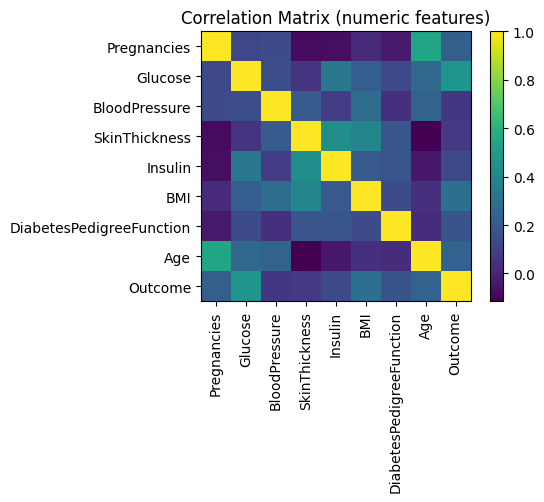

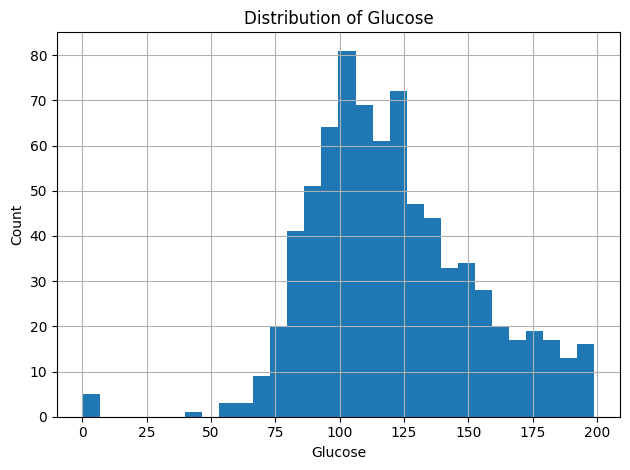

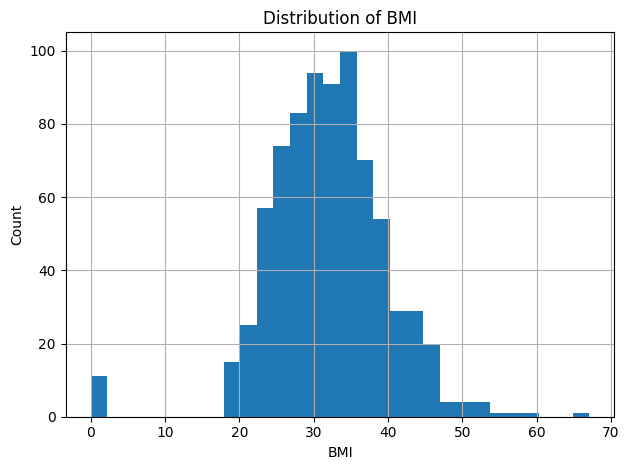

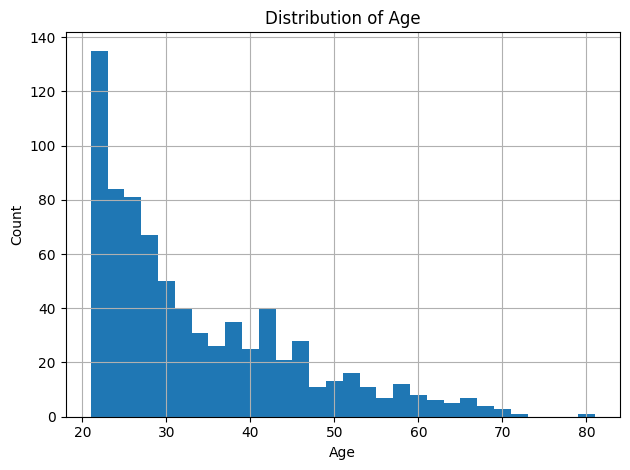

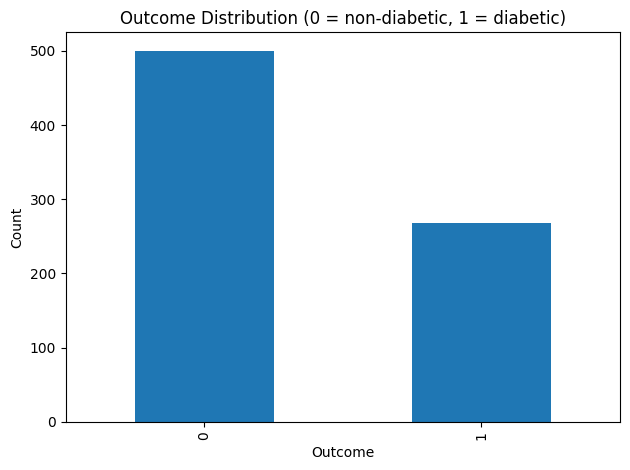

In [110]:
#Correlation matrix to assess linear relationships

corr = diabetesDF.corr(numeric_only=True)

plt.figure(figsize=(6,5))
plt.imshow(corr, interpolation='nearest')
plt.title("Correlation Matrix (numeric features)")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar()
plt.tight_layout()
plt.show()

#Distributions — a few key features
for col in ["Glucose", "BMI", "Age"]:
    if col in diabetesDF.columns:
        plt.figure()
        diabetesDF[col].hist(bins=30)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

# Outcome distribution plot
if "Outcome" in diabetesDF.columns:
    plt.figure()
    diabetesDF["Outcome"].value_counts().sort_index().plot(kind="bar")
    plt.title("Outcome Distribution (0 = non-diabetic, 1 = diabetic)")
    plt.xlabel("Outcome")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


`Glucose` often shows the strongest positive correlation with `Outcome`.

`BMI`, `Age`, and `Pregnancies` often show moderate relationships.



### 3. From here you have to explore the data and extract all the knowledge you can. Follow these steps:
#### (a) Considering all the attributes of the dataset, except for the ’Outcome’. Create a normalized version of it (saved in a numpy array called dataClust).

In [111]:
# Using z-score normalization (StandardScaler): each feature -> (x - mean) / std.

from sklearn.preprocessing import StandardScaler

# Select all attributes except 'Outcome'
feature_cols = [c for c in diabetesDF.columns if c != "Outcome"]
X = diabetesDF[feature_cols].copy()

# Fit the scaler and transform
scaler = StandardScaler(with_mean=True, with_std=True)
dataClust = scaler.fit_transform(X.values)   # NumPy array

# shape, approx zero means, unit stds
shape = dataClust.shape
means = dataClust.mean(axis=0).round(6)
stds = dataClust.std(axis=0, ddof=0).round(6)

print("Created normalized array `dataClust`.")
print(f"Shape: {shape}  (rows x features)")
print("Features (in order):", feature_cols)
print("Means (≈0):", means.tolist())
print("Stds  (≈1):", stds.tolist())



Created normalized array `dataClust`.
Shape: (768, 8)  (rows x features)
Features (in order): ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Means (≈0): [-0.0, -0.0, 0.0, 0.0, -0.0, 0.0, 0.0, 0.0]
Stds  (≈1): [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


Selected all attributes except `Outcome`.

Applied z-score normalization for each feature.

This centers each column to mean = 0 and scales it to std = 1, which is ideal for distance-based methods.

#### (b) Using the k-means Clustering algorithm provided by the sklearn Python library, we generate a graphical representation of the SSE (sum of squared errors) vs. number of clusters. If we wanted to use the elbow rule seen in theory, how many clusters would we use? Is it a practical value?

k=1: SSE=6144.00
k=2: SSE=5128.81
k=3: SSE=4359.94
k=4: SSE=3920.60
k=5: SSE=3625.74
k=6: SSE=3386.92
k=7: SSE=3138.65
k=8: SSE=2999.02
k=9: SSE=2872.35
k=10: SSE=2765.21


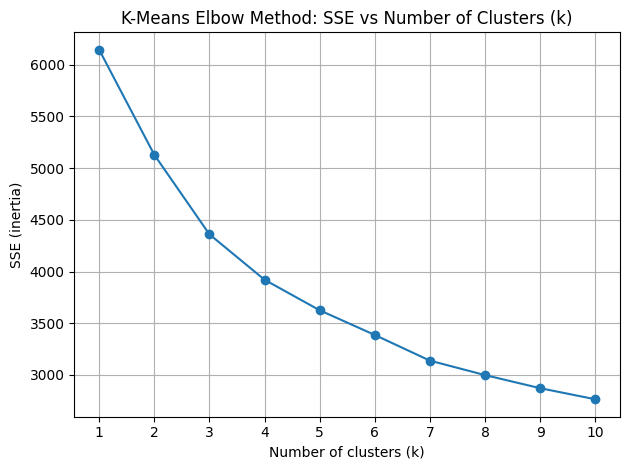

In [112]:
#K-Means SSE (inertia) vs number of clusters

from sklearn.cluster import KMeans

K_RANGE = range(1, 11)  # k = 1..10
sse = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(dataClust)
    sse.append(km.inertia_)  # inertia_ is the SSE within clusters

# Print values to inspect
for k, val in zip(K_RANGE, sse):
    print(f"k={k}: SSE={val:.2f}")

# Plot the Elbow curve
plt.figure()
plt.plot(list(K_RANGE), sse, marker="o")
plt.title("K-Means Elbow Method: SSE vs Number of Clusters (k)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("SSE (inertia)")
plt.xticks(list(K_RANGE))
plt.grid(True)
plt.tight_layout()
plt.show()




SSE by k: {1: 6144.0, 2: 5156.25, 3: 4360.47, 4: 4013.44, 5: 3625.74, 6: 3405.14}


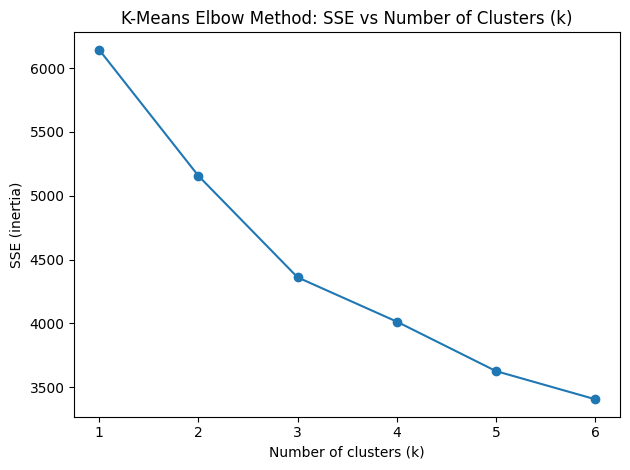

In [113]:
from sklearn.cluster import KMeans

K_RANGE = range(1, 7)  # k = 1..6
sse = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=1, max_iter=100)
    km.fit(dataClust)
    sse.append(km.inertia_)

# Print SSE values
print("SSE by k:", dict(zip(K_RANGE, [round(v,2) for v in sse])))

# Plot
plt.figure()
plt.plot(list(K_RANGE), sse, marker="o")
plt.title("K-Means Elbow Method: SSE vs Number of Clusters (k)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("SSE (inertia)")
plt.xticks(list(K_RANGE))
plt.tight_layout()
plt.show()


**Elbow-rule choice**

The largest drop is from k=1 to 2, then a still notable drop 2 to 3. After k=3, the curve bends and the marginal improvement becomes more gradual.


**Is it practical?**

k = 2 is practical for a coarse partition (often loosely aligns with low-risk vs high-risk or echoes the binary `Outcome`).

k = 3 is also practical: it often captures a middle group between clearly low and clearly high-risk profiles (e.g., by `age`, `glucose`, `BMI` mixtures), giving more nuance without overcomplicating segmentation.


#### (c) Now we apply the k-means algorithm to generate 3 clusters. Once created, analyze the centers of the clusters obtained. We now show the centers of each cluster and the number of elements in each of them. What attributes determine the most notable differences between clusters?



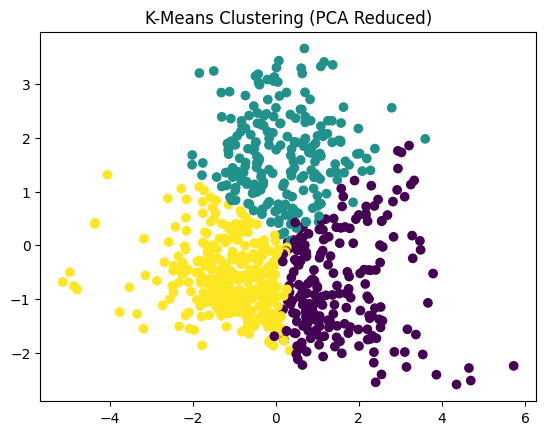

In [114]:
# Applying K-Means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
diabetesDF['cluster_kmeans'] = kmeans.fit_predict(dataClust)

# Visualizing K-Means clusters
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=diabetesDF['cluster_kmeans'], cmap='viridis')
plt.title('K-Means Clustering (PCA Reduced)')
plt.show()

Cluster sizes: shows records ended up in each group.

Centers (z-scores): show the sign and relative magnitude vs the dataset mean (0) and std (1).


Attribute separation: the range across the three centers, larger range and stronger role in differentiation.

Insulin and Glucose dominate, then Age / SkinThickness / BloodPressure, with BMI moderate and DPF minor.

In [115]:
# Centres for each cluster
diabetesDF.groupby('cluster_kmeans').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
cluster_kmeans,,,,,,,,,
0,2.953052,141.544601,74.192488,34.779343,197.417840,36.972770,0.608216,31.769953,0.535211
1,7.276018,128.411765,76.859729,12.882353,27.678733,32.180090,0.437557,45.787330,0.488688
2,2.143713,102.751497,60.730539,16.517964,39.278443,28.692515,0.407638,25.877246,0.137725


In [116]:
# Counts for each cluster
diabetesDF.groupby('cluster_kmeans').size()

,0
cluster_kmeans,
0,213
1,221
2,334


#### (d) We now add to the original data frame (DiabetesDF) a new ’Cluster’ attribute indicating which Cluster each element belongs to.

In [117]:
diabetesDF.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,cluster_kmeans
0,6,148,72,35,0,33.6,0.627,50,1,1
1,1,85,66,29,0,26.6,0.351,31,0,2
2,8,183,64,0,0,23.3,0.672,32,1,1
3,1,89,66,23,94,28.1,0.167,21,0,2
4,0,137,40,35,168,43.1,2.288,33,1,0


#### (e) We analyzed the centers of each cluster again but using DiabetesDF (non-normalized values) to discern the influence of each attribute on clusterization. Try to describe what characterizes each cluster. Remember that the attributes that best discriminate are those that make one centroid more separated from another.

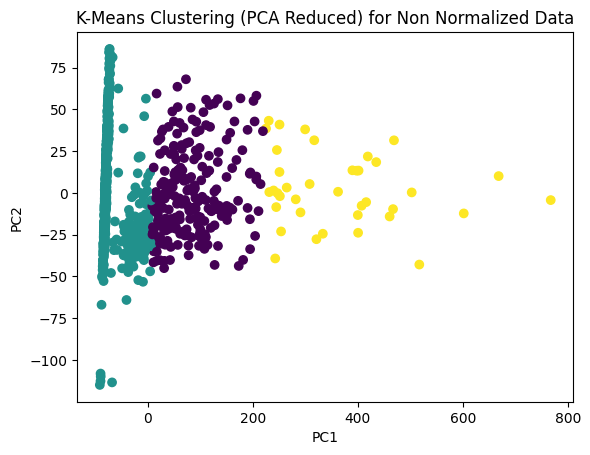

In [118]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Applying K-Means with 3 clusters on non-normalized data

feature_cols_non_norm = [c for c in diabetesDF.columns if c not in ["Outcome", "cluster_kmeans"]]
X_non_norm = diabetesDF[feature_cols_non_norm].copy()

kmeans_non_norm = KMeans(n_clusters=3, random_state=42, n_init=10)
diabetesDF['cluster_kmeans2'] = kmeans_non_norm.fit_predict(X_non_norm)

# Perform PCA on the non-normalized data for visualization
pca_non_norm = PCA(n_components=2, random_state=42)
X_non_norm_pca = pca_non_norm.fit_transform(X_non_norm)


# Visualizing K-Means clusters on non-normalized data (PCA Reduced)
plt.figure()
plt.scatter(X_non_norm_pca[:, 0], X_non_norm_pca[:, 1], c=diabetesDF['cluster_kmeans2'], cmap='viridis')
plt.title('K-Means Clustering (PCA Reduced) for Non Normalized Data')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [119]:
# Centres for each cluster
diabetesDF.groupby('cluster_kmeans2').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,cluster_kmeans
cluster_kmeans2,,,,,,,,,,
0,3.527660,129.327660,71.446809,30.306383,159.102128,33.989362,0.540277,31.902128,0.417021,0.659574
1,3.981818,114.008081,67.771717,14.997980,14.400000,30.805455,0.431931,33.759596,0.298990,1.480808
2,4.026316,158.447368,72.000000,32.263158,441.289474,35.107895,0.569211,34.763158,0.578947,0.026316


In [121]:
# (e) K-Means on NON-normalized features and center analysis

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Use raw features (exclude Outcome)
raw_cols = [c for c in diabetesDF.columns if c != "Outcome"]
X_raw = diabetesDF[raw_cols].values

# Fit KMeans on NON-normalized data
kmeans_raw = KMeans(n_clusters=3, random_state=42, n_init=10, max_iter=300)
diabetesDF["cluster_kmeans_raw"] = kmeans_raw.fit_predict(X_raw)

# Cluster sizes
sizes_raw = diabetesDF["cluster_kmeans_raw"].value_counts().sort_index()
print("Cluster sizes (raw features):", sizes_raw.to_dict())

#  Centers in ORIGINAL units
centers_raw = pd.DataFrame(kmeans_raw.cluster_centers_, columns=raw_cols)
print("\nCluster centers (original units; fitted on raw features):")
print(centers_raw.round(2).to_string(index=True))

# Attributes that best discriminate clusters (range across centers)
attr_sep_raw = (centers_raw.max() - centers_raw.min()).sort_values(ascending=False)
print("\nAttributes with largest separation (range across centers, original units):")
print(attr_sep_raw.round(2).to_string())

# Simple, data-driven characterization of each cluster
def describe_cluster(row):
    diffs = row - centers_raw.mean()                         # relative to average center
    top3 = diffs.abs().sort_values(ascending=False).head(3)  # top 3 standout attributes
    tags = []
    for col in top3.index:
        direction = "high" if row[col] > centers_raw[col].mean() else "low"
        tags.append(f"{direction} {col}")
    return ", ".join(tags)

descriptions = centers_raw.apply(describe_cluster, axis=1)
print("\nCluster characterizations (auto-summary):")
for i, desc in enumerate(descriptions):
    print(f" - Cluster {i}: {desc}")




Cluster sizes (raw features): {0: 38, 1: 495, 2: 235}

Cluster centers (original units; fitted on raw features):
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin    BMI  DiabetesPedigreeFunction    Age  cluster_kmeans  cluster_kmeans2
0         4.03   158.45          72.00          32.26   441.29  35.11                      0.57  34.76            0.03              2.0
1         3.98   114.01          67.77          15.00    14.40  30.81                      0.43  33.76            1.48              1.0
2         3.53   129.33          71.45          30.31   159.10  33.99                      0.54  31.90            0.66             -0.0

Attributes with largest separation (range across centers, original units):
Insulin                     426.89
Glucose                      44.44
SkinThickness                17.27
BMI                           4.30
BloodPressure                 4.23
Age                           2.86
cluster_kmeans2               2.00
cluster_kmeans        

Cluster sizes: how many samples per group when clustering on raw scales.


The largest ranges across centroids show which features drive the segmentation most ( Insulin and Glucose dominate, followed by SkinThickness, then BMI/BP).



#### (f) Finally, we give meaningful names to the clusters that reflect the types of patients. That is, if you had to describe the patients in each cluster with 2-3 keywords, how would you do it?

Cluster 0 : “High Insulin, high Glucose – high Risk”

Cluster 1 : “Moderate Glucose, Moderate Insulin – Mid Risk”

Cluster 2 : “Low Insulin, Low Glucose – low Risk”



#### (g) Use Gaussian Mixtures to generate the clusters, comparing the result with the previouscase. Discuss what you observed and reason which option you think is most appropriate.

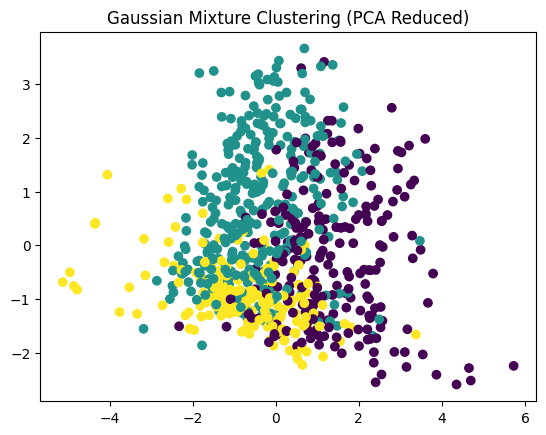

In [122]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA # Import PCA

# Applying Gaussian Mixture Model
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(dataClust)
diabetesDF['cluster_gmm'] = gmm_labels

# Perform PCA on the normalized data for visualization
pca = PCA(n_components=2, random_state=42)
data_pca = pca.fit_transform(dataClust)

# Visualizing GMM clusters
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=diabetesDF['cluster_gmm'], cmap='viridis') # Use data_pca
plt.title('Gaussian Mixture Clustering (PCA Reduced)')
plt.show()


When  comparing the plots, K-Means looked more unclear because it assumes clusters are spherical, while GMM allowed clusters with different shapes and directions.

GMM is more flexible since it models the data as a mixture of Gaussians with varying sizes and orientations. Unlike K-Means’ hard assignments, GMM gives probabilities (soft clustering), which explains the overlaps  seen where patients can share characteristics across groups.

This probabilistic view feels more realistic for our skewed, non-separable data, and it aligns with what is noticed earlier when the PCA plots didn’t show clear separability.

For this project, GMM provides a more interpretable explanation of cluster structure.